### Imports

(ﾉ◕ヮ◕)ﾉ*:･ﾟ✧ Starting Homework 4 while having the flu, let's see how bad it looks when I am 70 percent better!

Date: 3/9/2025
ಠ▃ಠ I am seeing in a blur, but I have to do a little something, or I will forget about it for the rest of the week.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Functions?

In [8]:
def invert_eos(u_target, P_target, rho_init, T_init, mu=4, tol=1e-6, max_iter=10000): ## To be fair, I think that is what I need to put.
    """
    Solve for density (rho) and temperature (T) given specific internal energy (u) and pressure (P).
    """
    # Constants
    k_B = 1.38e-16  # Boltzmann constant in erg/K
    m_u = 1.66e-24  # Atomic mass unit in g
    a_rad = 7.56e-15  # Radiation constant in erg cm^-3 K^-4
    
    # Initial guesses
    rho, T = rho_init, T_init

    rho_values = []
    T_values = []

   # Compute initial Helmholtz free energy
    u_init = (3/2) * (k_B / (mu * m_u)) * T + (a_rad / rho) * T**4
    f_init = u_init - T * ((3/2) * (k_B / (mu * m_u)) * np.log(T**(3/2) / rho) + (4/3) * (a_rad / rho) * T**4)
    print(f"Initial Helmholtz free energy: {f_init:.6e} erg/g")

    # Compute initial pressure and specific internal energy
    P_init = (rho * k_B / (mu * m_u)) * T + (1/3) * a_rad * T**4
    e_init = (3/2) * (k_B / (mu * m_u)) * T + (a_rad / rho) * T**4
    print("Initial conditions:")
    print(f"Initial pressure: {P_init:.6e} erg/cm^3")
    print(f"Initial specific internal energy: {e_init:.6e} erg/g")
    
    print("Iteration | rho (g/cm^3) | T (K)        | delta_rho     | delta_T")
    print("--------------------------------------------------------------------------")
    
    for i in range(max_iter):
        # Compute the current values of u and P from the EOS
        u = (3/2) * (k_B / (mu * m_u)) * T + (a_rad / rho) * T**4
        P = (rho * k_B / (mu * m_u)) * T + (1/3) * a_rad * T**4

        # Compute f1 and f2
        f1 = u - u_target
        f2 = P - P_target

        # Compute the Jacobian matrix elements
        du_dT = (3/2) * (k_B / (mu * m_u)) + 4 * (a_rad / rho) * T**3
        du_drho = - (a_rad / rho**2) * T**4
        dP_dT = (rho * k_B / (mu * m_u)) + (4/3) * a_rad * T**3
        dP_drho = (k_B / (mu * m_u)) * T

        # Construct the Jacobian matrix
        J = np.array([[du_drho, du_dT],
                      [dP_drho, dP_dT]])

        # Construct the function vector
        F = np.array([-f1, -f2])

        # Solve for the corrections using linear system J * [d_rho, d_T] = -[f1, f2]
        delta = np.linalg.solve(J, F)

        # Apply the corrections
        rho += delta[0]
        T += delta[1]

        # Store values for plotting
        rho_values.append(rho)
        T_values.append(T)

        # Print iteration details
        print(f"{i+1:9d} | {rho:.6e} | {T:.6e} | {delta[0]:.6e} | {delta[1]:.6e}")
        
        # Check for convergence
        if np.abs(delta[0]) < tol and np.abs(delta[1]) < tol:
            print("\n", "CoNVeRGenCEE REEEacHEDED!")
            break
    else:
        print("WARNING: Maximum iterations reached without convergence.", "\n", "ಠ▃ಠ AHHHHHHHHHH!")

    # Plot iterations
    plt.figure(figsize=(8, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(rho_values) + 1), rho_values, marker='o', linestyle=':')
    plt.xlabel("Iterations")
    plt.ylabel("Density (g/cm^3)")
    plt.title("Convergence of Density")
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(T_values) + 1), T_values, marker='o', linestyle='-')
    plt.xlabel("Iterations")
    plt.ylabel("Temperature (K)")
    plt.title("Convergence of Temperature")
    
    plt.tight_layout() ## ಠ╭╮ಠ Eww, why did I do that?
    plt.show()

    # Verify the solution
    u_final = (3/2) * (k_B / (mu * m_u)) * T + (a_rad / rho) * T**4
    P_final = (rho * k_B / (mu * m_u)) * T + (1/3) * a_rad * T**4
    print("Final conditions:")
    print(f"Final computed specific internal energy: {u_final:.6e} erg/g (target: {u_target:.6e})")
    print(f"Final computed pressure: {P_final:.6e} erg/cm^3 (target: {P_target:.6e})")
    
    return rho, T

### The rest of the code 
##### (o゜▽゜)o☆ I can go for a spaghetti sandwich that has pecorino romano, provolone con pan de manteca o un pan cubano.

Initial Helmholtz free energy: -1.008007e+21 erg/g
Initial conditions:
Initial pressure: 2.330313e+14 erg/cm^3
Initial specific internal energy: 3.873470e+14 erg/g
Iteration | rho (g/cm^3) | T (K)        | delta_rho     | delta_T
--------------------------------------------------------------------------
        1 | -1.836602e+03 | 1.239626e+10 | -1.837602e+03 | 1.238626e+10
        2 | -1.836625e+03 | 9.297216e+09 | -2.248227e-02 | -3.099047e+09
        3 | -1.836692e+03 | 6.972945e+09 | -6.672985e-02 | -2.324271e+09
        4 | -1.836892e+03 | 5.229767e+09 | -2.006584e-01 | -1.743178e+09
        5 | -1.837502e+03 | 3.922429e+09 | -6.100093e-01 | -1.307338e+09
        6 | -1.839374e+03 | 2.942007e+09 | -1.871605e+00 | -9.804223e+08
        7 | -1.845165e+03 | 2.206835e+09 | -5.790815e+00 | -7.351716e+08
        8 | -1.863259e+03 | 1.655720e+09 | -1.809467e+01 | -5.511150e+08
        9 | -1.920817e+03 | 1.242885e+09 | -5.755762e+01 | -4.128348e+08
       10 | -2.112421e+03 | 9.343471e+0

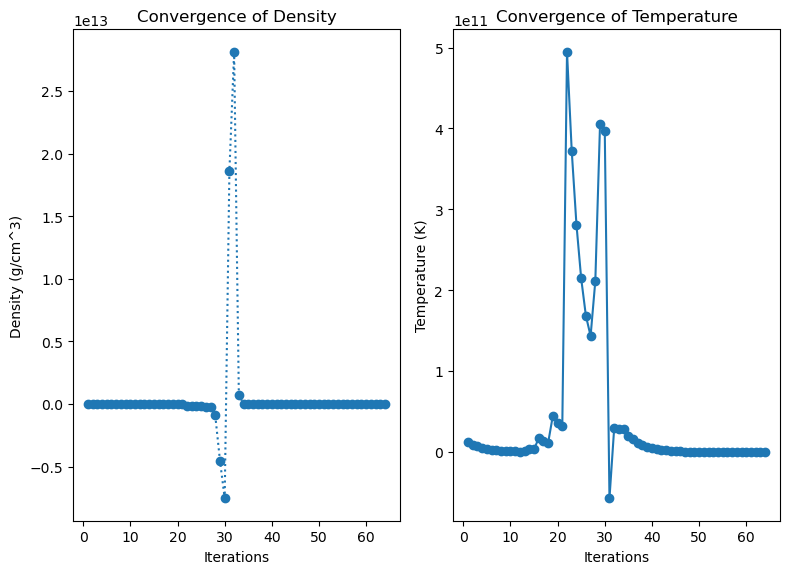

Final conditions:
Final computed specific internal energy: 9.000087e+17 erg/g (target: 9.000087e+17)
Final computed pressure: 6.005630e+14 erg/cm^3 (target: 6.005630e+14)

 Solved density: 0.0020003270035344133 g/cm^3
Solved temperature: 22086321.185635034 K


In [18]:
# Example usage with test values
u_target = 90000.87e13  # erg/g
P_target = 60056.3e10  # erg/cm^3
rho_init = 1.0  # g/cm^3
T_init = 1e7  # K

rho_solution, T_solution = invert_eos(u_target, P_target, rho_init, T_init)
print("\n",f"Solved density: {rho_solution} g/cm^3")
print(f"Solved temperature: {T_solution} K")

Initial Helmholtz free energy: -1.008007e+21 erg/g
Initial conditions:
Initial pressure: 2.330313e+14 erg/cm^3
Initial specific internal energy: 3.873470e+14 erg/g
Iteration | rho (g/cm^3) | T (K)        | delta_rho     | delta_T
--------------------------------------------------------------------------
        1 | 7.648697e-01 | 4.033630e+06 | -2.351303e-01 | -5.966370e+06
        2 | 5.216195e-01 | 1.353811e+06 | -2.432502e-01 | -2.679819e+06
        3 | 4.488108e-02 | 1.238932e+06 | -4.767384e-01 | -1.148785e+05
        4 | 1.464720e-03 | 1.217237e+06 | -4.341636e-02 | -2.169495e+04
        5 | 1.072834e-03 | 1.018295e+06 | -3.918862e-04 | -1.989425e+05
        6 | 9.896433e-04 | 9.984495e+05 | -8.319082e-05 | -1.984540e+04
        7 | 9.883667e-04 | 9.979948e+05 | -1.276642e-06 | -4.547372e+02
        8 | 9.883662e-04 | 9.979947e+05 | -5.325933e-10 | -1.352899e-01
        9 | 9.883662e-04 | 9.979947e+05 | -5.551550e-17 | -2.023988e-08

 CoNVeRGenCEE REEEacHEDED!


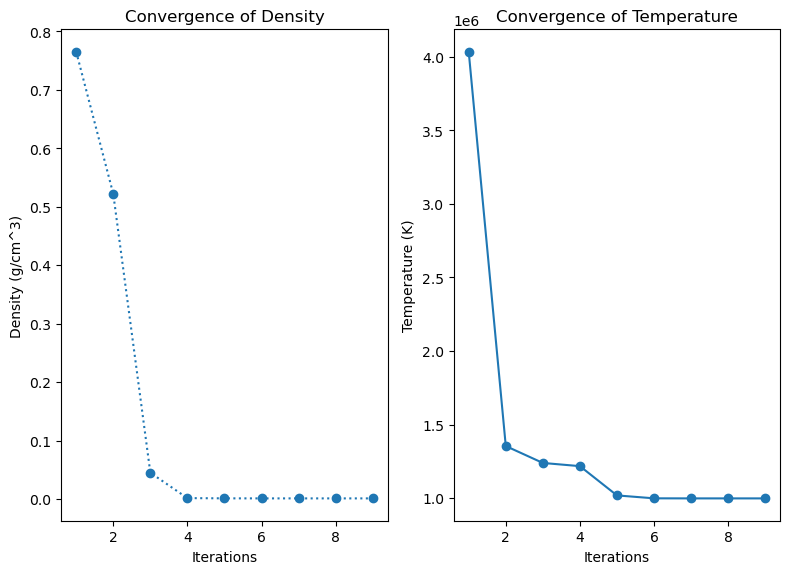

Final conditions:
Final computed specific internal energy: 3.870000e+13 erg/g (target: 3.870000e+13)
Final computed pressure: 2.300000e+10 erg/cm^3 (target: 2.300000e+10)

 Solved density: 0.0009883661649603842 g/cm^3
Solved temperature: 997994.6760717371 K


In [20]:
# Example usage with test values
u_target = 3.87e13  # erg/g
P_target = 2.3e10  # erg/cm^3
rho_init = 1.0  # g/cm^3
T_init = 1e7  # K

rho_solution, T_solution = invert_eos(u_target, P_target, rho_init, T_init)
print("\n",f"Solved density: {rho_solution} g/cm^3")
print(f"Solved temperature: {T_solution} K")

Date: 3/10/2025
ಥ_ಥ I am not sure if the code is good or not? And why did I get the Helmholtz Free Energy? Why did the flu make me do unecessary things?